In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

### static LCI +  three GWP: 
- GWP100
- pGWP-fixed vs. dp-CO2 

In [2]:
wind  = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
#hydro = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_run-of-river_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_reservoir_CN-asRoW_US-asQC_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

In [3]:
def tidy(df, tech_label):
    parts = df["Activity"].str.split(", ", expand=True)
    out = df.copy()
    out["Technology"] = tech_label
    out["Country"]    = parts[3].str[:2]
    out["SSP"]        = parts[4]
    out["Year"]       = parts[5].astype(int)
    return out[["Technology", "Country", "SSP", "Year",
                "gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]]

all_df = pd.concat(
    [tidy(wind,  "Wind"),
     tidy(hydro, "Hydro"),
     tidy(pv,    "PV")],
    ignore_index=True,
)

# Keep only 2030 & 2050
df = all_df[all_df["Year"].isin([2030, 2050])].copy()

# 2. Long format over metrics
metric_cols = ["gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]
df_long = df.melt(
    id_vars=["Technology", "Country", "SSP", "Year"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

# 3. Compute rank per (Country, SSP, Year, Metric)
df_long["Rank"] = df_long.groupby(
    ["Country", "SSP", "Year", "Metric"]
)["Score"].rank(method="dense", ascending=True)

df_long


,Technology,Country,SSP,Year,Metric,Score,Rank
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905,2.0
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832,2.0
2,Wind,CN,SSP2-M,2030,gwp100,0.037723,2.0
3,Wind,CN,SSP2-M,2050,gwp100,0.031185,2.0
4,Wind,CN,SSP5-H,2030,gwp100,0.038734,2.0
...,...,...,...,...,...,...,...
103,PV,US,SSP1-VLLO,2050,pGWP100_dpCO2,0.006184,1.0
104,PV,US,SSP2-M,2030,pGWP100_dpCO2,0.020048,2.0
105,PV,US,SSP2-M,2050,pGWP100_dpCO2,0.012654,1.0
106,PV,US,SSP5-H,2030,pGWP100_dpCO2,0.020952,2.0


In [4]:
df_long.sort_values([ "SSP","Year", "Country", "Technology"	]).to_excel("plot_rankshift_hydro_v2_reservoir.xlsx")

### plot 

#### function

In [5]:
def rank_shift_plot_cleanSeparated(
    df_long,
    metric_order,
    metric_labels,
    tech_colors,
    fig_title="Rank shifts across GWP metrics",
    years=(2030, 2050),
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    lw=3.0,
    sep=0.03,
    anot_off=0.16
):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    df = df_long.copy()
    df["Rank"] = (
        df.groupby(["Country", "SSP", "Year", "Metric"])["Score"]
          .rank(method="dense", ascending=True)
    )

    dotted_2050 = (0, (1, 3))
    year_ls    = {2030: "solid", 2050: dotted_2050}
    year_alpha = {2030: 1.0, 2050: 0.9}
    zmap = {2030: 5, 2050: 4}

    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(countries),
        figsize=(12, 12),   # 2nd parameter 10 to 12 -> taller figure
        sharex=True,
        sharey=True,
    )
    plt.subplots_adjust(
        top=0.90,
        bottom=0.18,
        hspace=0.55,         # MORE vertical breathing room
        wspace=0.20,
    )

      
    plt.subplots_adjust(top=0.88, bottom=0.20, hspace=0.35, wspace=0.18)

    x = np.arange(len(metric_order))

    for i, ssp in enumerate(ssps):
        for j, ct in enumerate(countries):
            ax = axes[i, j]
            sub = df[(df["SSP"] == ssp) & (df["Country"] == ct)]

            for tech in ["Hydro", "PV", "Wind"]:
                sub_t = sub[sub["Technology"] == tech]

                for yr in years:
                    tdf = sub_t[sub_t["Year"] == yr]
                    if tdf.empty:
                        continue

                    y_rank  = tdf.set_index("Metric")["Rank"].reindex(metric_order)
                    y_score = tdf.set_index("Metric")["Score"].reindex(metric_order)

                    shift     = sep if yr == 2030 else -sep
                    y_shifted = y_rank + shift

                    ax.plot(
                        x,
                        y_shifted,
                        linestyle=year_ls[yr],
                        color=tech_colors[tech],
                        alpha=year_alpha[yr],
                        linewidth=lw,
                        marker="x",
                        markersize=7,
                        zorder=zmap[yr],
                    )

                    # ---- BOXED ANNOTATIONS ----
                    for xi, yi, sc in zip(x, y_shifted, y_score):
                        if pd.isna(sc):
                            continue

                        val = sc * 1000.0
                        y_text = yi + anot_off if yr == 2030 else yi - anot_off
                        va     = "bottom" if yr == 2030 else "top"

                        ax.text(
                            xi,
                            y_text,
                            f"{val:.1f}",
                            ha="center",
                            va=va,
                            fontsize=9.5,
                            color="white",
                            bbox=dict(
                                    boxstyle="round,pad=0.18",      # slightly tighter box
                                    facecolor=tech_colors[tech],
                                    edgecolor="black",
                                    linewidth=0.9,
                                    linestyle="solid" if yr == 2030 else "dashed",
                                    alpha=0.8,                     # lets grid & lines breathe
                                ),
                            zorder=10,
                        )

            ax.set_title(f"{ct}, {ssp}", fontsize=14, pad=8)
            ax.set_xticks(x)

            if i == len(ssps) - 1:
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=25,
                    ha="right",
                    fontsize=12,
                )
            else:
                ax.set_xticklabels([])

            ax.set_yticks([1, 2, 3])
            ax.set_ylim(0.2, 3.8)
            if j == 0:
                ax.set_ylabel("Rank (1 = lowest GWP)", fontsize=13)

            ax.grid(axis="y", linestyle=":", alpha=0.3)

    # Legend
    handles, labels = [], []
    for tech in ["Hydro", "PV", "Wind"]:
        for yr in years:
            h, = axes[0, 0].plot(
                [],
                [],
                linestyle=year_ls[yr],
                color=tech_colors[tech],
                linewidth=lw,
                marker="x",
                markersize=7,
            )
            handles.append(h)
            labels.append(f"{tech} {yr}")

    fig.legend(
        handles,
        labels,
        title="Technology / Year",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=6,
        fontsize=12,
        frameon=True,
    )

    fig.suptitle(fig_title, fontsize=16, y=0.97)
    return fig, axes


#### plot 

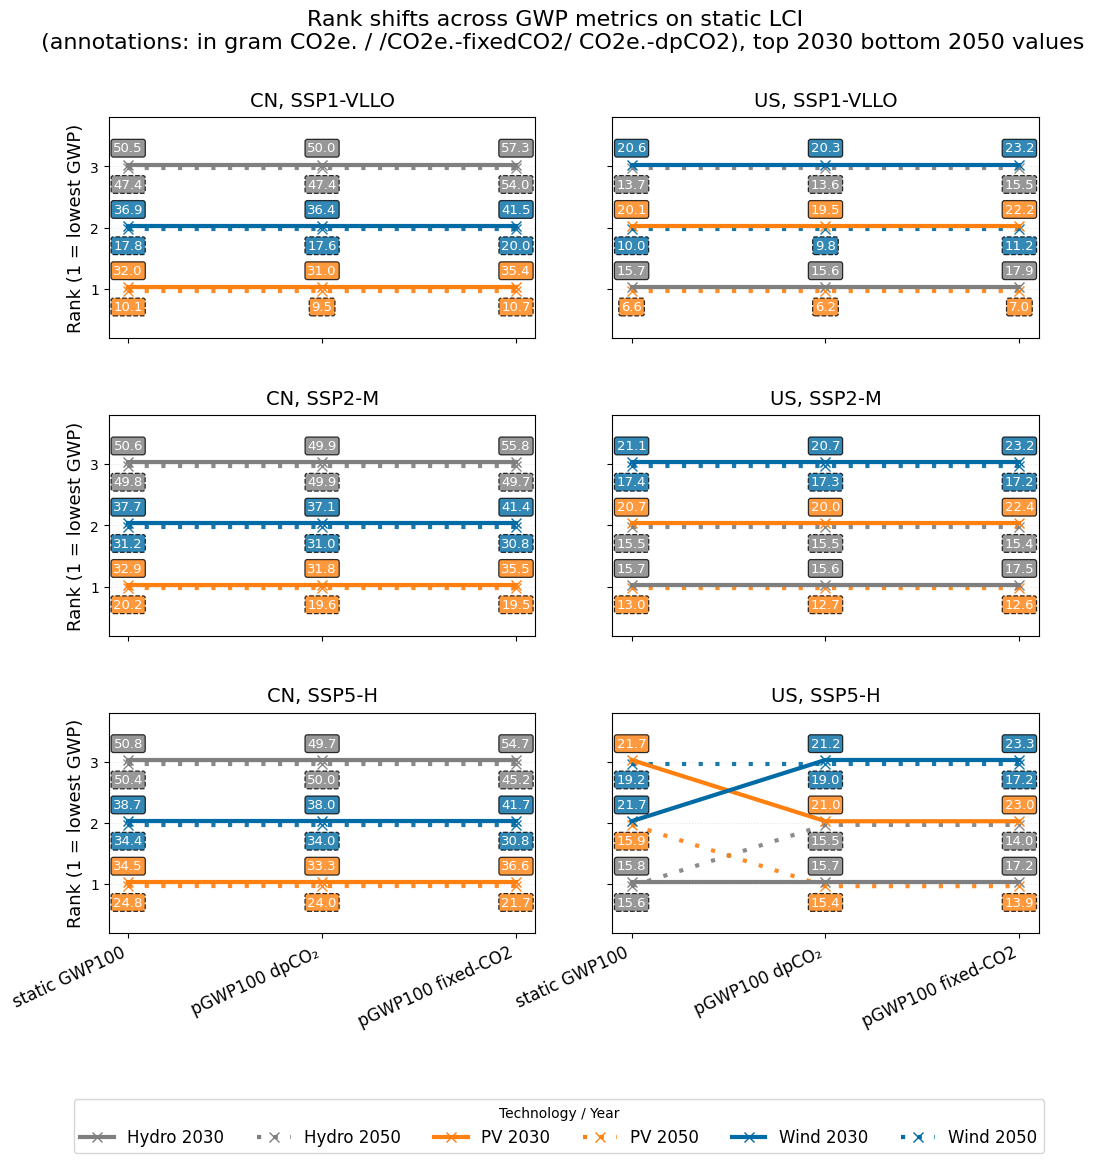

In [6]:
metric_order = ["gwp100", 
                "pGWP100_dpCO2",
                "pGWP100_fixedCO2" ]
metric_labels = {
    "gwp100": "static GWP100",
    "pGWP100_fixedCO2": "pGWP100 fixed-CO2",
    "pGWP100_dpCO2": "pGWP100 dpCO₂",
}
tech_colors = {"PV":"#FF800E","Wind":"#006BA4","Hydro":"#7F7F7F"}

fig, axes = rank_shift_plot_cleanSeparated(
    df_long,
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
    fig_title=  "Rank shifts across GWP metrics on static LCI \n (annotations: in gram CO2e. / /CO2e.-fixedCO2/ CO2e.-dpCO2), top 2030 bottom 2050 values",
)

The apparent reversal in the relative ranking of hydropower between 2030 and 2050 results from the interaction between (i) rapidly decarbonizing upstream industrial supply chains for wind and photovoltaic systems under SSP1-VLLO (e.g., electricity, steel, aluminum, and silicon production), and (ii) comparatively stable methane emissions associated with hydro-reservoir operation. As background electricity and material production become progressively cleaner toward 2050, residual reservoir methane emissions represent a growing share of total life-cycle climate impacts, causing hydropower to appear relatively less favorable than wind and solar in low-emission scenarios. This effect is structural to prospective LCA under deep decarbonization pathways and should not be interpreted as an absolute increase in hydropower emissions.